# 00 — Figure style gallery

**Purpose.** A *style preview*, not a thesis float. It renders the 10 figure
types from the design-system task so they can be eyeballed side-by-side against
the hand-drawn Lucidchart conceptual diagrams in
`tba4925-masters-thesis/Chapters/{02,04,05}/.../figures/*.png`.

Everything is driven by the single style source of truth,
`src/plotting/style.py` (`StyleConfig.apply_rcparams()` + the palette/diagram
helpers). Previews are written to `style-preview/` — **never** into `figures/`
or the thesis. Data is loaded only through the existing cache reader
(`thesis_compute.load_all`, cache-only, no Azure); a few demo panels use clearly
labelled synthetic data because the gallery previews *style*, not results.

### Gallery → real-figure mapping

9 of the 10 types already exist as real thesis figures (the gallery calls their
**actual** `thesis_figures` / `charts` functions, so styling is pulled in, not
re-invented). Only the **Sankey is net-new** (absent from notebooks 01–05 and
the thesis figure manifest).

| # | Gallery type | Status | Real figure — notebook → file |
|---|--------------|--------|-------------------------------|
| 1 | Sankey — distributed byte flow | **NET-NEW** | *(none — not in 01–05 nor the manifest)* |
| 2 | Raincloud (violin·box·points), min marked | real | `02-rq1-single-node` → `06-single-machine-wall-clock-time.png` |
| 3 | Grouped bar + CI whiskers | demo (superseded) | the RQ1 grid was replaced by the raincloud (type 2) in `02` |
| 4 | ECDF, p50/p95/p99 guides | real | `02-rq1-single-node` → `06-single-machine-latency-ecdf.png` |
| 5 | Line + CI band + ideal ref | real* | `03-rq2-distributed` → `06-distributed-speedup.png`, `06-distributed-efficiency.png` |
| 6 | Heatmap — winners + numeric+colourbar | real | `04-rq3-synthesis` → `06-winners-matrix.png`; `01-measurement-quality` → `06-results-coverage-*.png` |
| 7 | Scatter/bubble cost vs time, log–log | real | `03-rq2-distributed` → `06-distributed-cost-time-pareto.png` |
| 8 | Stacked bar — 4-term cost | real | `02-rq1-single-node` → `06-single-machine-operational-cost.png` |
| 9 | Forest plot — Vargha–Delaney A12 | real fn† | `04-rq3-synthesis` → `06-vargha-delaney-forest.png` |
| 10 | Slopegraph / bump — ranking stability | real | `04-rq3-synthesis` → `06-ranking-stability.png` |

\* The real RQ2 speed-up/efficiency figures draw **min-estimator point lines +
an ideal reference**, not a shaded CI band (the estimator is the one-sided
minimum). Type 5 shows the real `fig_efficiency` *and* a small synthetic
CI-band demo so the band style is previewable.
† The real forest runs `a12_forest(pooled_pairwise_table(...))` (~47 s of
bootstrap); this preview feeds the **real** `fig_a12_forest` a small
representative **synthetic** `forest_df` to keep the gallery fast.

### Flagged

- **Font.** The thesis *body* is Computer Modern (no font package in
  `packages.sty`); figures use a humanist sans to match the diagrams (face =
  **Lato**). `Source Sans 3` is intended but not installed here, so figures
  resolve to **Open Sans** (a Lato near-twin) — much closer to the diagrams than
  the former **DejaVu Sans** fallback. See the font-comparison panel below.
- **broadcast / partitioned colours.** Per `CLAUDE.md` / `packages.sty`:
  broadcast → `thesissteel`, partitioned → `thesissage`, default → `thesisgray`.
  *Not* broadcast=teal / partitioned=coral (those would collide with
  duckdb=teal / postgis=coral).

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.plotting import style as S
from src.plotting.style import PALETTE, StyleConfig, tint, shade
from src.plotting import thesis_figures as tf
from src.plotting.charts import plot_coverage_heatmap
from src.analysis import thesis_compute as tc
from src.analysis.tables import build_cost_summary

style = StyleConfig()
style.apply_rcparams()

_avail = {f.name for f in fm.fontManager.ttflist}
print("Resolved sans:", S.resolved_sans(),
      "| mono:", next((m for m in S.MONO_STACK if m in _avail), "monospace"))

PREVIEW = Path("style-preview"); PREVIEW.mkdir(exist_ok=True)
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)

RQ1_W = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]
RQ1_C = ["duckdb", "postgis", "local"]
# fast builders only (no bootstrap; pooled-pairwise is skipped — see type 9)
scaling = tc.rq2_scaling(successful)
single  = tc.rq2_single_node(successful)
failed  = tc.rq2_failed(successful, experiments)
phase   = tc.rq2_phase(successful)
pareto  = tc.rq2_pareto(successful, cost_summary)
sysvals = tc.rq3_system_values(successful, cost_summary)
winners = tc.rq3_winners(sysvals)
ranks   = tc.rq3_ranks(sysvals)
print("loaded:", successful.shape, "| previews ->", PREVIEW.resolve())

Resolved sans: Source Sans 3 | mono: JetBrains Mono


loaded: (394834, 26) | previews -> /home/jatha/Code/ntnu/doppa-analytics/style-preview


## Font check — Open Sans (resolved) vs DejaVu Sans (former fallback)

Same content in both faces. Open Sans (top) is the humanist sans matching the
Lato of the `05-*` conceptual diagrams; DejaVu Sans (bottom) is wider/heavier.
Saved to `style-preview/00-font-comparison.png`.

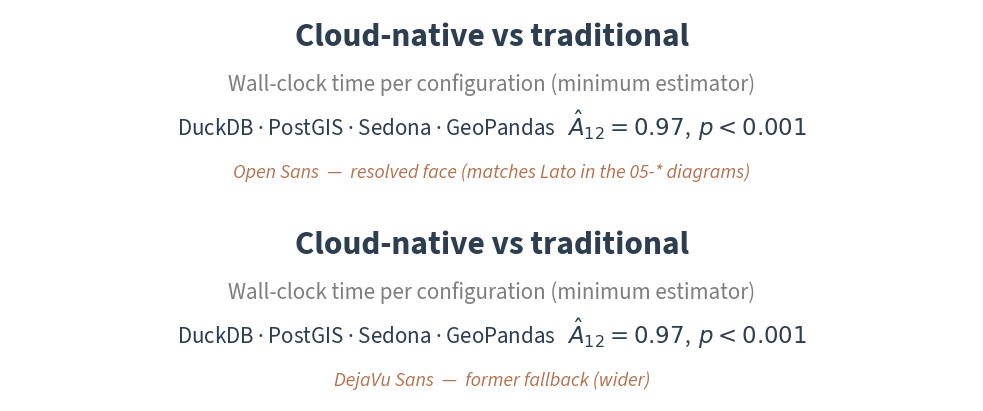

In [2]:
def _sample(ax, fam, caption):
    with mpl.rc_context({"font.sans-serif": [fam, "DejaVu Sans"]}):
        ax.text(0.5, 0.82, "Cloud-native vs traditional", ha="center",
                fontsize=16, fontweight="bold", color=PALETTE["thesisslate"])
        ax.text(0.5, 0.56, "Wall-clock time per configuration (minimum estimator)",
                ha="center", fontsize=11, color=PALETTE["thesisgray"])
        ax.text(0.5, 0.30,
                r"DuckDB · PostGIS · Sedona · GeoPandas   "
                r"$\hat{A}_{12}=0.97$,  $p<0.001$",
                ha="center", fontsize=11, color=PALETTE["thesisslate"])
        ax.text(0.5, 0.06, caption, ha="center", fontsize=9.5, fontstyle="italic",
                color=PALETTE["thesiscoral"])
    ax.axis("off")

fig, axes = plt.subplots(2, 1, figsize=(8.2, 3.3))
_sample(axes[0], "Open Sans", "Open Sans  —  resolved face (matches Lato in the 05-* diagrams)")
_sample(axes[1], "DejaVu Sans", "DejaVu Sans  —  former fallback (wider)")
fig.savefig(PREVIEW / "00-font-comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 1 — Sankey · distributed-join byte flow  **(NET-NEW)**

Not present in notebooks 01–05 or the thesis figure manifest. Built from the
conceptual-diagram helpers in `style.py` (`rounded_node`, `ribbon`,
`loop_ribbon`, `bottom_legend`, `two_line_title`) so it matches the rounded-node
+ ribbon + bottom-legend look of the `05-*` diagrams. **Measured bytes** for one
representative national-scale join (**broadcast · 8 workers · large tier**,
medians over 9 iterations of run `2026-05-26-OY0CN3`).

Three nodes, left→right: **ADLS Gen2 — GeoParquet** (object storage, cloud-native
teal, Norway East) → **Executors — Spark** (infrastructure gray, Sweden Central)
→ **Driver — result** (gray, Sweden Central). Ribbons are **constant width along
their whole length** (no per-ribbon arrowheads — the shuffle loop is a uniform
half-annulus); a single **direction-of-flow arrow beneath the figure** carries
the left→right sense. Channels:

- **read** — storage → executors; teal because it carries GeoParquet data. The
  only hop crossing the dashed *Norway East | Sweden Central* boundary, so the
  only **billed egress** — marked by the warm dot at the crossing (the cost
  event), not by recolouring the whole ribbon.
- **shuffle** — **one** intra-cluster exchange, a self-loop on the executors node.
  Spark reports it as two counters, `shuffle_write_bytes` (map side) and
  `shuffle_read_bytes` (reduce side); they are the same bytes measured twice
  (here within <0.01 %). The loop shows them as its two legs — left = write,
  right = read, **each labelled with its own value** — rather than two ribbons
  that would double-count the ~13 GB exchanged once.
- **collect** — executors → driver; per-municipality result rows.

**Honest-width design.** `read` = `executor_input_bytes_read` and `shuffle` =
`shuffle_write_bytes` (≈ `shuffle_read_bytes`) share the Spark executor-byte
scale, so their widths are **proportional to each other**. Each carries its
**p50 and min–max range (n = 9)** — the right tail runs ~3× the median (read up
to ~36 GB), so the figure must not read as one canonical number.

**Flagged.** `collect` has **no Spark result-bytes counter**. It is sized by
`result_cardinality` (357 rows); the driver network counter
(`network_bytes_received` ≈ 62 KB) is a different measurement layer (OS network,
not Spark I/O), so it is **never used to width the ribbon** — `collect` is a
fixed **hairline off the GB scale**, labelled by row count. Ribbon widths are
relative within the figure; read & shuffle share one scale, collect does not.

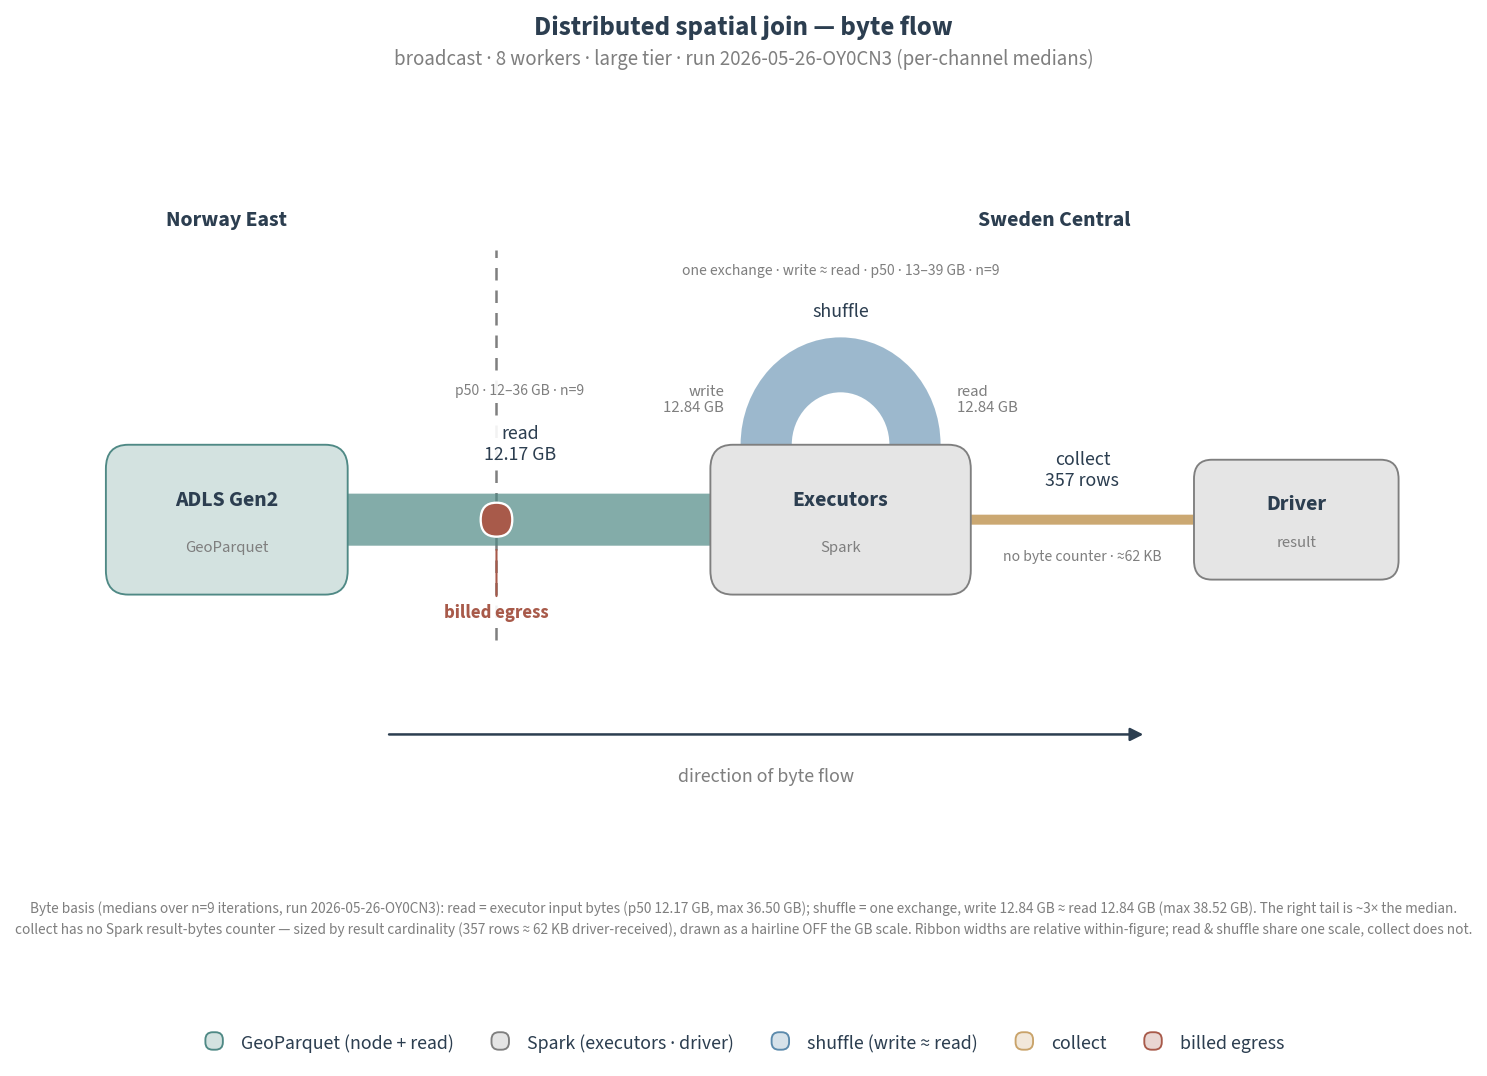

In [3]:
# Real byte volumes for one representative distributed-join run (cache-only).
rep = successful[(successful.workload_type == "national-scale-spatial-join")
                 & (successful.configuration == "databricks-broadcast-8-nodes")
                 & (successful.dataset_size == "large")]
def _stats(col):
    v = rep[col].dropna()
    return (float(np.median(v)), float(v.min()), float(v.max()), int(len(v)))

read_med, read_lo, read_hi, N = _stats("executor_input_bytes_read")  # storage->exec; only billed (cross-region) hop
shw_med, shw_lo, shw_hi, _ = _stats("shuffle_write_bytes")            # shuffle WRITE (map side)
shr_med, shr_lo, shr_hi, _ = _stats("shuffle_read_bytes")             # shuffle READ (reduce side) ~= write
rows    = float(np.median(rep["result_cardinality"].dropna()))         # collect: per-municipality result rows
drv_rx  = float(np.median(rep["network_bytes_received"].dropna()))     # driver-received bytes (proxy only)
# Shuffle write & read are the two sides of ONE exchange (data written by map tasks is the same data
# read back by reduce tasks); here they differ by <0.01%. Drawn as a single loop — out-leg = write,
# back-leg = read, each labelled with its own value — not two ribbons, which would double-count.
# FLAG: collect has NO Spark result-bytes counter and lives on a different metric layer (OS network,
# KB) than read/shuffle (Spark I/O, GB). Drawn as a fixed hairline OFF the GB scale, labelled by rows.

def _gb(b):  return f"{b/1e9:.2f} GB"
def _rng(lo, hi):  return f"p50 · {lo/1e9:.0f}–{hi/1e9:.0f} GB · n={N}"

GRAY, SLATE = PALETTE["thesisgray"], PALETTE["thesisslate"]
TEAL, STEEL, AMBER = PALETTE["thesisteal"], PALETTE["thesissteel"], PALETTE["thesisamber"]
BRICK = PALETTE["thesisbrick"]
BB = dict(facecolor="white", edgecolor="none", pad=1.6, alpha=0.9)  # masks lines behind labels

maxb = max(read_med, shw_med)
W = lambda b: 0.55 * (b / maxb)   # read & shuffle: true linear share of the executor-byte scale
W_COLLECT = 0.10                  # collect: deliberate hairline, NOT proportional (see FLAG above)

fig, ax = plt.subplots(figsize=(12, 6.4))
ax.set_xlim(0, 15); ax.set_ylim(0, 7.4); ax.axis("off")
ny = 3.5                           # flow centerline
nh = 1.5; ytop = ny + nh / 2       # node height & top edge

# Dashed region boundary: Norway East (storage) | Sweden Central (compute).
xbd = 4.6
ax.plot([xbd, xbd], [2.3, 6.2], ls=(0, (5, 4)), color=GRAY, lw=1.2, zorder=0)
ax.text(1.7, 6.4, "Norway East", ha="center", va="bottom",
        fontsize=10.5, fontweight="bold", color=SLATE)
ax.text(10.6, 6.4, "Sweden Central", ha="center", va="bottom",
        fontsize=10.5, fontweight="bold", color=SLATE)

# Nodes: GeoParquet storage = cloud-native teal; executors & driver = infrastructure gray.
S.rounded_node(ax, (0.4, ny - nh / 2), 2.6, nh, "ADLS Gen2", "GeoParquet", role="cloudnative")
S.rounded_node(ax, (6.9, ny - nh / 2), 2.8, nh, "Executors", "Spark", role="infrastructure")
S.rounded_node(ax, (12.1, ny - 0.6), 2.2, 1.2, "Driver", "result", role="infrastructure")

# 1) read: storage -> executors, constant-width band carrying GeoParquet data (teal).
#    Crosses the region boundary => the only billed egress, marked by the warm dot.
S.ribbon(ax, (3.0, ny), (6.9, ny), W(read_med), color=TEAL, alpha=0.7)
ax.text(4.85, ny + W(read_med) / 2 + 0.30, f"read\n{_gb(read_med)}",
        ha="center", va="bottom", fontsize=9.5, color=SLATE, bbox=BB, zorder=7)
ax.text(4.85, ny + W(read_med) / 2 + 0.96, _rng(read_lo, read_hi),
        ha="center", va="bottom", fontsize=7.5, color=GRAY, bbox=BB, zorder=7)
ax.add_patch(mpl.patches.FancyBboxPatch(
    (xbd - 0.17, ny - 0.17), 0.34, 0.34,
    boxstyle="round,pad=0,rounding_size=0.17", facecolor=BRICK,
    edgecolor="white", linewidth=1.1, zorder=6))
ax.annotate("billed egress", xy=(xbd, ny - W(read_med) / 2),
            xytext=(xbd, ny - W(read_med) / 2 - 0.58),
            ha="center", va="top", fontsize=9, fontweight="bold", color=BRICK,
            bbox=BB, zorder=7, arrowprops=dict(arrowstyle="-", color=BRICK, lw=1.0))

# 2) shuffle: ONE intra-cluster exchange as a constant-width self-loop (half-annulus, no arrowhead).
#    Its two legs ARE the two metrics: left foot = shuffle write, right foot = shuffle read (~ equal).
fl, fr = 7.5, 9.1
S.loop_ribbon(ax, fl, fr, ytop, W(shw_med), color=STEEL, alpha=0.6)
arch_top = ytop + (fr - fl) / 2 + W(shw_med) / 2
ax.text(fl - 0.45, ytop + 0.45, f"write\n{_gb(shw_med)}", ha="right", va="center",
        fontsize=8, color=GRAY)
ax.text(fr + 0.45, ytop + 0.45, f"read\n{_gb(shr_med)}", ha="left", va="center",
        fontsize=8, color=GRAY)
ax.text((fl + fr) / 2, arch_top + 0.16, "shuffle",
        ha="center", va="bottom", fontsize=9.5, color=SLATE, bbox=BB, zorder=7)
ax.text((fl + fr) / 2, arch_top + 0.60, f"one exchange · write ≈ read · {_rng(shw_lo, shw_hi)}",
        ha="center", va="bottom", fontsize=7.5, color=GRAY, bbox=BB, zorder=7)

# 3) collect: executors -> driver, constant-width hairline (result aggregates to ~per-municipality rows).
S.ribbon(ax, (9.7, ny), (12.1, ny), W_COLLECT, color=AMBER, alpha=0.95)
ax.text(10.9, ny + 0.30, f"collect\n{int(rows)} rows",
        ha="center", va="bottom", fontsize=9.5, color=SLATE, bbox=BB, zorder=7)
ax.text(10.9, ny - 0.30, "no byte counter · ≈62 KB", ha="center", va="top",
        fontsize=7.5, color=GRAY, bbox=BB, zorder=7)

# Flow-direction indicator beneath the figure (the only arrow; ribbons carry none).
ax.add_patch(mpl.patches.FancyArrowPatch(
    (3.4, 1.35), (11.6, 1.35), arrowstyle="-|>", mutation_scale=13,
    color=SLATE, lw=1.2, zorder=2))
ax.text(7.5, 1.02, "direction of byte flow", ha="center", va="top",
        fontsize=9.5, color=GRAY)

S.two_line_title(fig, "Distributed spatial join — byte flow",
                 f"broadcast · 8 workers · large tier · run {RUN_ID} (per-channel medians)")
fig.text(0.5, 0.04,
         f"Byte basis (medians over n={N} iterations, run {RUN_ID}): read = executor input bytes "
         f"(p50 {_gb(read_med)}, max {_gb(read_hi)}); shuffle = one exchange, write {_gb(shw_med)} "
         f"≈ read {_gb(shr_med)} (max {_gb(shw_hi)}). The right tail is ~3× the median.\n"
         "collect has no Spark result-bytes counter — sized by result cardinality "
         f"({int(rows)} rows ≈ {drv_rx/1e3:.0f} KB driver-received), drawn as a hairline OFF the "
         "GB scale. Ribbon widths are relative within-figure; read & shuffle share one scale, collect does not.",
         ha="center", va="bottom", fontsize=7.3, color=GRAY, linespacing=1.5)
S.bottom_legend(fig, [("GeoParquet (node + read)", S.role_style("cloudnative")),
                      ("Spark (executors · driver)", S.role_style("infrastructure")),
                      ("shuffle (write ≈ read)", STEEL),
                      ("collect", AMBER),
                      ("billed egress", BRICK)], y=-0.10)
fig.savefig(PREVIEW / "01-sankey-byte-flow.png", dpi=150, bbox_inches="tight")
plt.show()

## 1b — Byte flow across all Spark runs (aggregated)  **(NET-NEW)**

The type-1 byte-flow design applied to **every** distributed run, not just the
representative one. Bytes read/shuffled depend on **dataset size** and **join
strategy**, not on worker count (the data volume is fixed), so worker count is
**pooled, not faceted**: each channel's value is the **pooled-iteration median**
across all worker counts, and the small range beneath it is the across-worker
spread (mostly instrumentation, not scaling). **Median** is used throughout —
robust to the ~3× per-run right tail and to the artifact spikes some worker
counts show.

Reads off the four panels: read band + shuffle loop thicken with size
(small → medium → large); `collect` is a 357-row hairline in every run; and
**partitioned shuffles ~2.8× more than broadcast** — its loop dwarfs its read
band, whereas broadcast's loop ≈ its read. All panels share one global GB scale,
so widths are comparable across panels.

**Data gap.** The partitioned strategy was benchmarked at the **small tier only**
(it is tagged *only tier run*), so the broadcast-vs-partitioned contrast is valid
at small; there are no partitioned medium/large runs in this run.

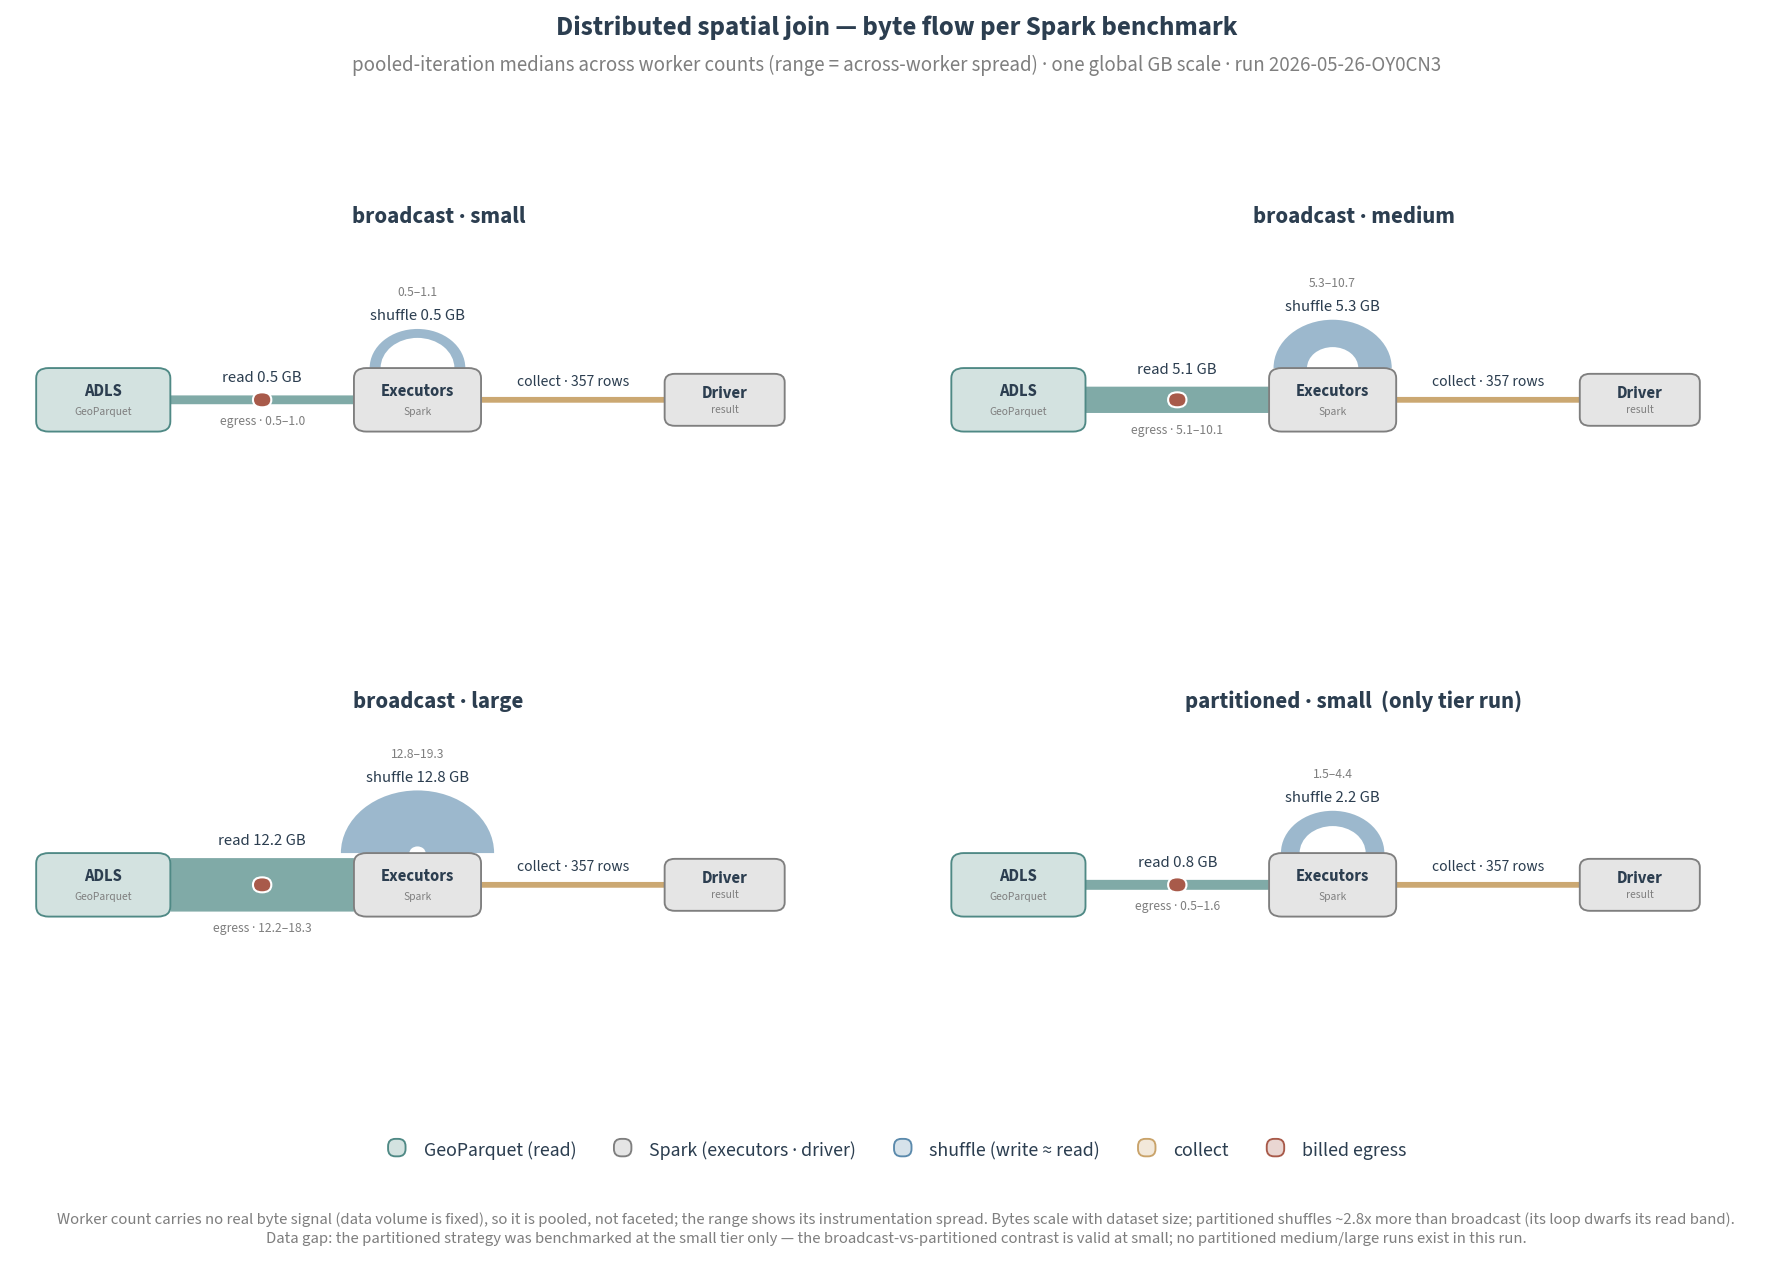

In [4]:
# 1b — the same byte-flow design applied to EVERY Spark run, aggregated (cache-only).
# Worker count carries no real byte signal (data volume is fixed), so it is POOLED, not
# faceted: each channel = pooled-iteration median over all worker counts; the small range
# beneath it = the across-worker spread (mostly instrumentation, not scaling). Median is
# used throughout (robust to the ~3x per-run right tail and to artifact spikes).
dist = successful[successful.workload_type == "national-scale-spatial-join"].copy()
_p = dist.configuration.str.extract(r"databricks-(?P<strategy>\w+)-(?P<nodes>\d+)-nodes")
dist["strategy"] = _p["strategy"]; dist["nodes"] = _p["nodes"].astype(float)

def _pooled(st, sz, col):
    sub = dist[(dist.strategy == st) & (dist.dataset_size == sz)]
    med = float(np.median(sub[col].dropna())) / 1e9           # pooled-iteration median
    nm = sub.groupby("nodes")[col].median() / 1e9             # per-worker-count medians
    return med, float(nm.min()), float(nm.max())

PANELS = [("broadcast", "small"), ("broadcast", "medium"),
          ("broadcast", "large"), ("partitioned", "small")]
gstats = {(st, sz): {
    "read": _pooled(st, sz, "executor_input_bytes_read"),
    "shuf": _pooled(st, sz, "shuffle_write_bytes"),
    "rows": int(np.median(dist[(dist.strategy == st) & (dist.dataset_size == sz)]
                          ["result_cardinality"].dropna())),
} for st, sz in PANELS}

GRAY, SLATE, BRICK = PALETTE["thesisgray"], PALETTE["thesisslate"], PALETTE["thesisbrick"]
TEAL, STEEL, AMBER = PALETTE["thesisteal"], PALETTE["thesissteel"], PALETTE["thesisamber"]
BBg = dict(facecolor="white", edgecolor="none", pad=1.2, alpha=0.9)
MAXB = max(max(gstats[p]["read"][0], gstats[p]["shuf"][0]) for p in PANELS)  # one shared scale
Wg = lambda gb: 0.12 + 0.85 * (gb / MAXB)

def _panel(ax, st, sz):
    s = gstats[(st, sz)]; rd, sf = s["read"], s["shuf"]
    ax.set_xlim(0, 12); ax.set_ylim(0, 7); ax.axis("off")
    yc = 2.7
    S.rounded_node(ax, (0.3, yc - 0.55), 1.9, 1.1, "ADLS", "GeoParquet", role="cloudnative", fontsize=8)
    S.rounded_node(ax, (4.8, yc - 0.55), 1.8, 1.1, "Executors", "Spark", role="infrastructure", fontsize=8)
    S.rounded_node(ax, (9.2, yc - 0.45), 1.7, 0.9, "Driver", "result", role="infrastructure", fontsize=8)
    S.ribbon(ax, (2.2, yc), (4.8, yc), Wg(rd[0]), color=TEAL, alpha=0.72)
    ax.add_patch(mpl.patches.FancyBboxPatch((3.5 - 0.13, yc - 0.13), 0.26, 0.26,
        boxstyle="round,pad=0,rounding_size=0.13", facecolor=BRICK, edgecolor="white",
        linewidth=1.0, zorder=6))
    ax.text(3.5, yc + Wg(rd[0]) / 2 + 0.18, f"read {rd[0]:.1f} GB", ha="center", va="bottom",
            fontsize=8, color=SLATE, bbox=BBg, zorder=7)
    ax.text(3.5, yc - Wg(rd[0]) / 2 - 0.18, f"egress · {rd[1]:.1f}–{rd[2]:.1f}", ha="center",
            va="top", fontsize=6.5, color=GRAY, zorder=7)
    fl, fr = 5.1, 6.3
    S.loop_ribbon(ax, fl, fr, yc + 0.55, Wg(sf[0]), color=STEEL, alpha=0.6)
    arch = yc + 0.55 + (fr - fl) / 2 + Wg(sf[0]) / 2
    ax.text((fl + fr) / 2, arch + 0.10, f"shuffle {sf[0]:.1f} GB", ha="center", va="bottom",
            fontsize=8, color=SLATE, bbox=BBg, zorder=7)
    ax.text((fl + fr) / 2, arch + 0.52, f"{sf[1]:.1f}–{sf[2]:.1f}", ha="center", va="bottom",
            fontsize=6.5, color=GRAY, zorder=7)
    S.ribbon(ax, (6.6, yc), (9.2, yc), 0.10, color=AMBER, alpha=0.95)
    ax.text(7.9, yc + 0.20, f"collect · {s['rows']} rows", ha="center", va="bottom",
            fontsize=7.5, color=SLATE, bbox=BBg, zorder=7)
    tag = f"{st} · {sz}" + ("  (only tier run)" if st == "partitioned" else "")
    ax.text(6.0, 5.7, tag, ha="center", va="bottom", fontsize=11, fontweight="bold", color=SLATE)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.6))
for ax, (st, sz) in zip(axes.ravel(), PANELS):
    _panel(ax, st, sz)
S.two_line_title(fig, "Distributed spatial join — byte flow per Spark benchmark",
                 "pooled-iteration medians across worker counts (range = across-worker spread) · "
                 f"one global GB scale · run {RUN_ID}")
S.bottom_legend(fig, [("GeoParquet (read)", S.role_style("cloudnative")),
                      ("Spark (executors · driver)", S.role_style("infrastructure")),
                      ("shuffle (write ≈ read)", STEEL),
                      ("collect", AMBER),
                      ("billed egress", BRICK)], y=-0.02)
fig.text(0.5, -0.05,
         "Worker count carries no real byte signal (data volume is fixed), so it is pooled, not "
         "faceted; the range shows its instrumentation spread. Bytes scale with dataset size; "
         "partitioned shuffles ~2.8x more than broadcast (its loop dwarfs its read band).\n"
         "Data gap: the partitioned strategy was benchmarked at the small tier only — the broadcast-vs-"
         "partitioned contrast is valid at small; no partitioned medium/large runs exist in this run.",
         ha="center", va="top", fontsize=8, color=GRAY, linespacing=1.5)
fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.10, hspace=0.20, wspace=0.08)
fig.savefig(PREVIEW / "01c-sankey-byte-flow-per-benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 — Raincloud (violin · box · jittered points), min estimator marked

**Real figure** — calls `thesis_figures.fig_rq1_time_grid`
(`02-rq1-single-node` → `06-single-machine-wall-clock-time.png`). Previewed on a
compact 1-workload × 2-tier subset.

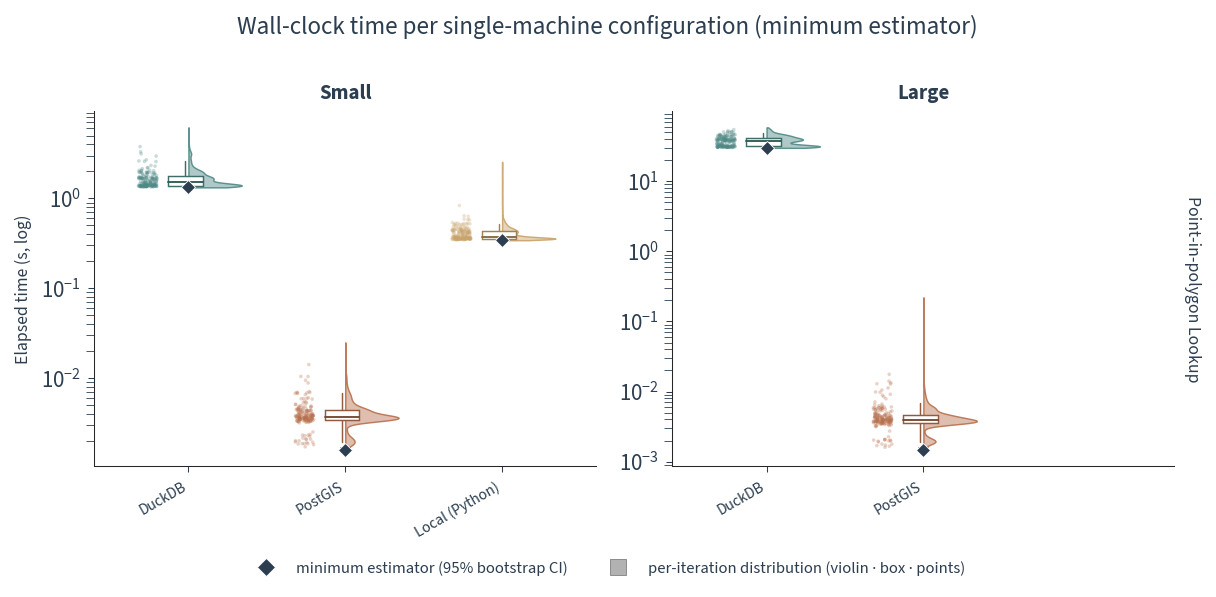

PosixPath('style-preview/02-raincloud-latency.png')

In [5]:
tf.fig_rq1_time_grid(successful, ["point-in-polygon-lookup"], RQ1_C,
                     ["small", "large"], style, PREVIEW / "02-raincloud-latency.png")

## 3 — Grouped bar with CI whiskers  *(demo — superseded by the raincloud)*

The RQ1 wall-clock grid was migrated from grouped bars + whiskers to the
raincloud (type 2). This demo rebuilds the grouped-bar+CI style from **real**
RQ1 data (minimum estimator + 95% bootstrap CI via `tf.estimate_ci`).

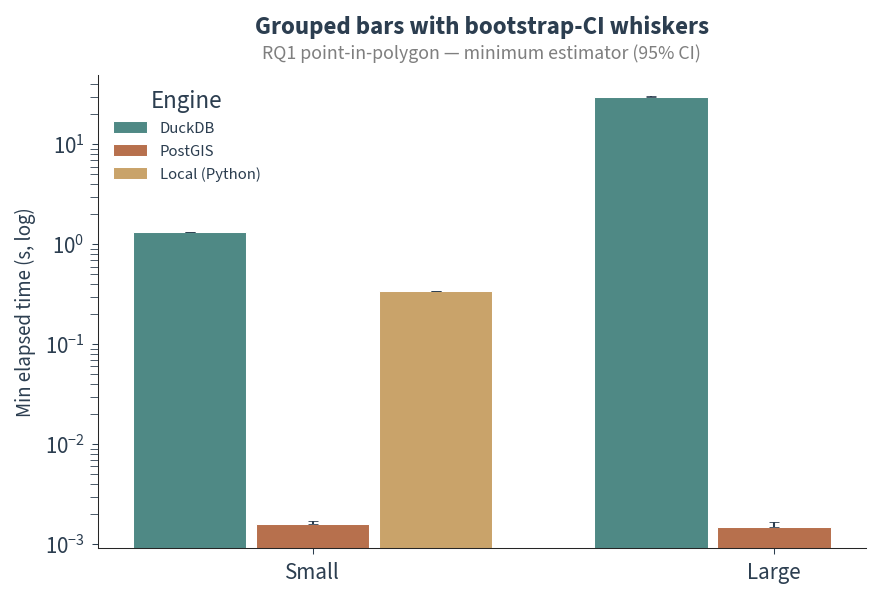

In [6]:
wl, tiers = "point-in-polygon-lookup", ["small", "large"]
fig, ax = plt.subplots(figsize=(6.6, 4.1))
xb = np.arange(len(tiers)); width = 0.8 / len(RQ1_C)
for j, cfg in enumerate(RQ1_C):
    pts, lo_err, hi_err = [], [], []
    for ds in tiers:
        v = successful[(successful.workload_type == wl) & (successful.dataset_size == ds)
                       & (successful.configuration == cfg)]["elapsed_time"].dropna().values
        if len(v):
            p, lo, hi = tf.estimate_ci(v, kind="min")
            le, he = max(p - lo, 0.0), max(hi - p, 0.0)  # min-estimator CI need not bracket point
        else:
            p, le, he = np.nan, 0.0, 0.0
        pts.append(p); lo_err.append(le); hi_err.append(he)
    off = (j - len(RQ1_C) / 2 + 0.5) * width
    ax.bar(xb + off, pts, width * 0.92, color=style.color(cfg), edgecolor="white",
           linewidth=0.5, label=style.label(cfg))
    ax.errorbar(xb + off, pts, yerr=[lo_err, hi_err], fmt="none",
                ecolor=PALETTE["thesisslate"], elinewidth=1.0, capsize=2.5)
ax.set_yscale("log"); ax.set_xticks(xb); ax.set_xticklabels([t.capitalize() for t in tiers])
ax.set_ylabel("Min elapsed time (s, log)")
ax.legend(fontsize=8, title="Engine")
S.two_line_title(ax, "Grouped bars with bootstrap-CI whiskers",
                 "RQ1 point-in-polygon — minimum estimator (95% CI)")
fig.savefig(PREVIEW / "03-grouped-bar-ci.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 — ECDF, p50/p95/p99 guides

**Real figure** — `thesis_figures.fig_rq1_latency_ecdf`
(`02-rq1-single-node` → `06-single-machine-latency-ecdf.png`).

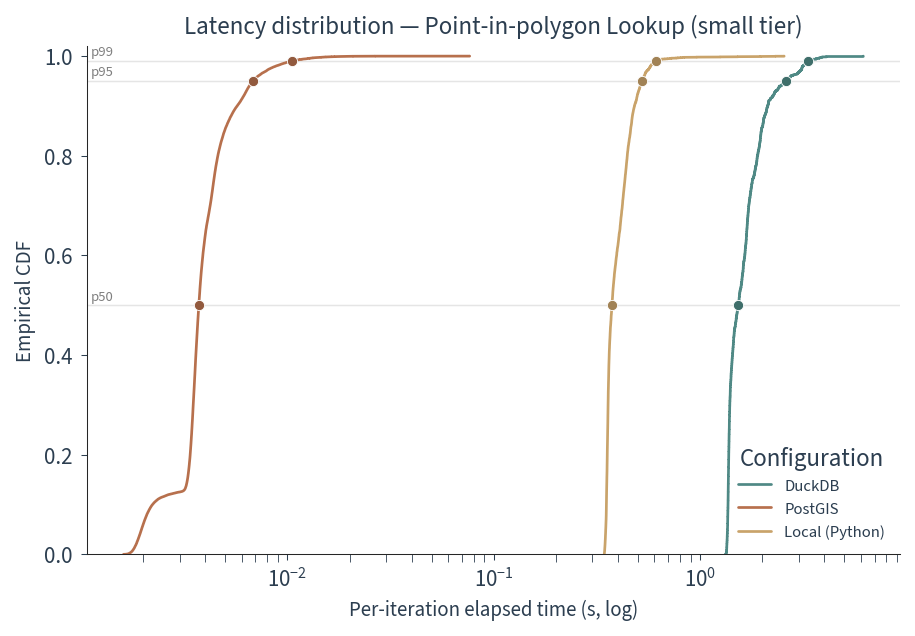

PosixPath('style-preview/04-latency-ecdf.png')

In [7]:
tf.fig_rq1_latency_ecdf(successful, "point-in-polygon-lookup", "small", RQ1_C,
                        style, PREVIEW / "04-latency-ecdf.png")

## 5 — Line + CI band with an ideal reference

**Real figure** — `thesis_figures.fig_efficiency`
(`03-rq2-distributed` → `06-distributed-efficiency.png`), which uses
min-estimator point lines + an `E = 1` ideal. Below it, a small **synthetic**
demo shows the shaded-CI-band variant of this style.

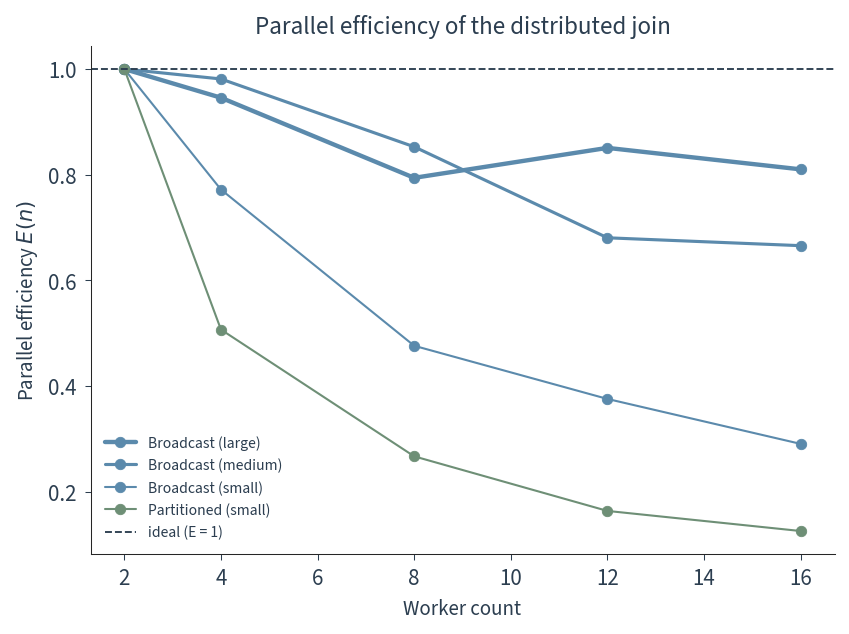

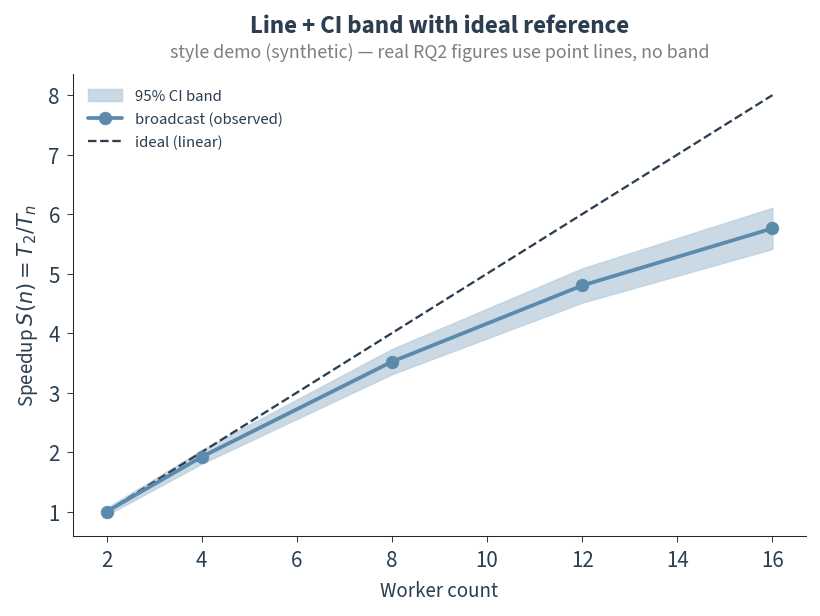

In [8]:
tf.fig_efficiency(scaling, style, PREVIEW / "05-distributed-efficiency.png")

w = np.array([2, 4, 8, 12, 16], float)
sp = (w / 2) * np.array([1.0, 0.96, 0.88, 0.80, 0.72])
err = sp * 0.06
fig, ax = plt.subplots(figsize=(6.3, 4.0))
ax.fill_between(w, sp - err, sp + err, color=tint(PALETTE["thesissteel"], 0.6),
                alpha=0.8, label="95% CI band", zorder=1)
ax.plot(w, sp, marker="o", color=PALETTE["thesissteel"], linewidth=1.8,
        label="broadcast (observed)", zorder=3)
ax.plot([2, 16], [1, 8], "--", color=PALETTE["thesisslate"], linewidth=1.1,
        label="ideal (linear)")
ax.set_xlabel("Worker count"); ax.set_ylabel(r"Speedup $S(n) = T_2 / T_n$")
ax.legend(fontsize=8)
S.two_line_title(ax, "Line + CI band with ideal reference",
                 "style demo (synthetic) — real RQ2 figures use point lines, no band")
fig.savefig(PREVIEW / "05-line-ci-band-demo.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Heatmap: winners matrix (categorical) + coverage (numeric + colourbar)

**Real figures** — `thesis_figures.fig_winners_matrix`
(`04-rq3-synthesis` → `06-winners-matrix.png`) and
`charts.plot_coverage_heatmap` (`01-measurement-quality` →
`06-results-coverage-single-machine.png`).

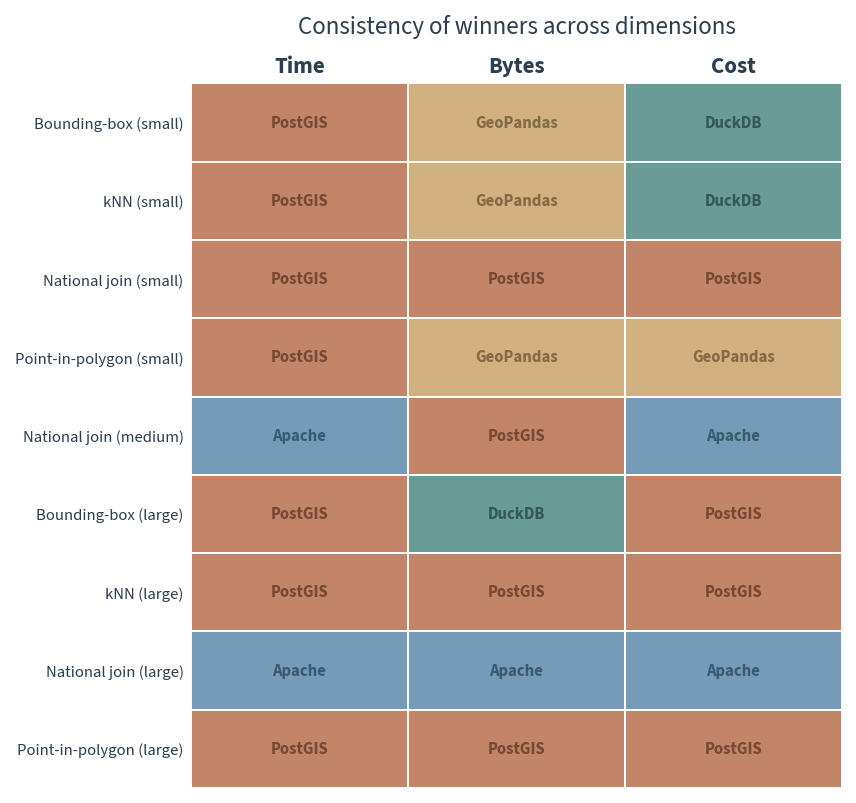

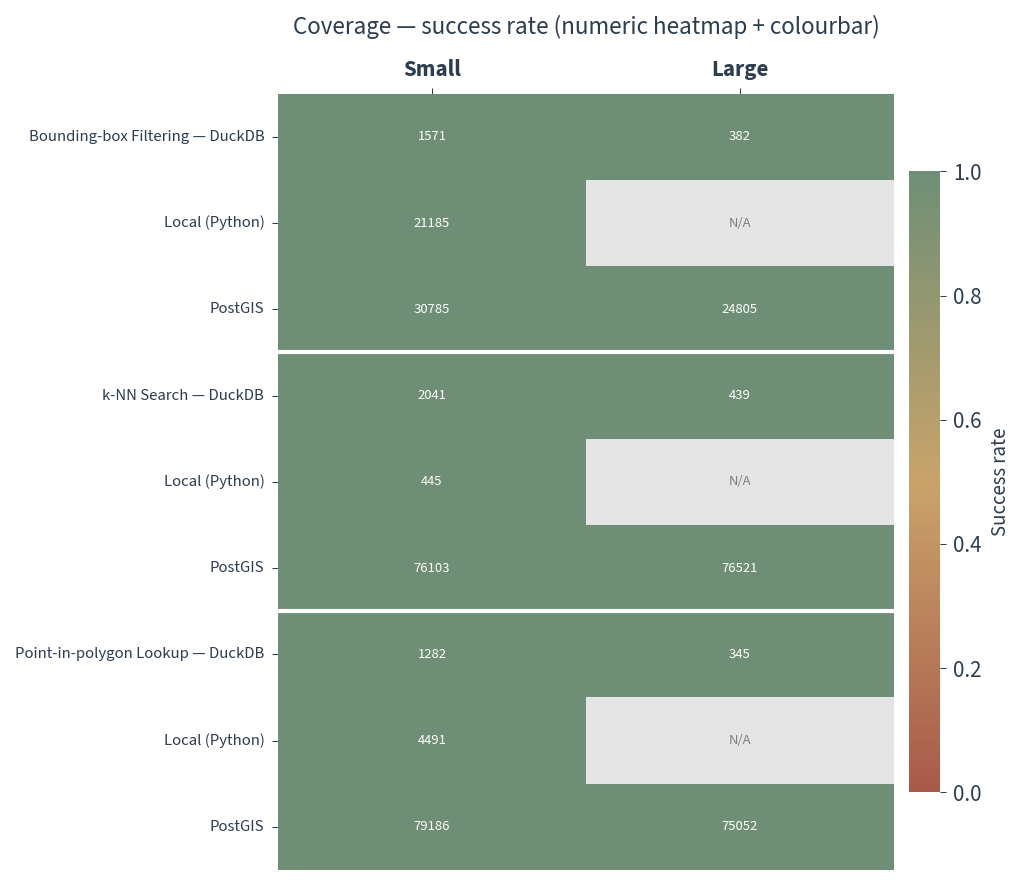

In [9]:
tf.fig_winners_matrix(winners, style, PREVIEW / "06-winners-matrix.png")
plot_coverage_heatmap(samples_df, successful, style, PREVIEW,
                      metadata_df=metadata_df, experiments=experiments,
                      workloads=RQ1_W, out_name="06-coverage-numeric",
                      title="Coverage — success rate (numeric heatmap + colourbar)")

## 7 — Scatter / bubble: cost vs time, log–log

**Real figure** — `thesis_figures.fig_cost_pareto`
(`03-rq2-distributed` → `06-distributed-cost-time-pareto.png`); the non-dominated
frontier is traced. (`fig_rq1_bytes_vs_time` is the marker-shape/bubble variant.)

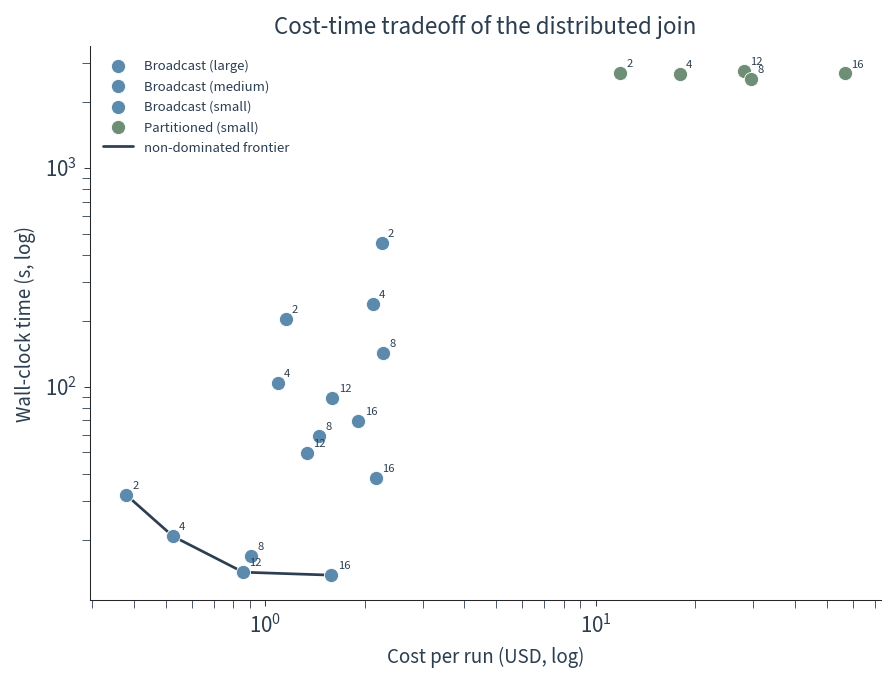

PosixPath('style-preview/07-cost-time-pareto.png')

In [10]:
tf.fig_cost_pareto(pareto, style, PREVIEW / "07-cost-time-pareto.png")

## 8 — Stacked bar: 4-term cost composition

**Real figure** — `thesis_figures.fig_rq1_operational_cost`
(`02-rq1-single-node` → `06-single-machine-operational-cost.png`): compute /
storage / operations / egress.

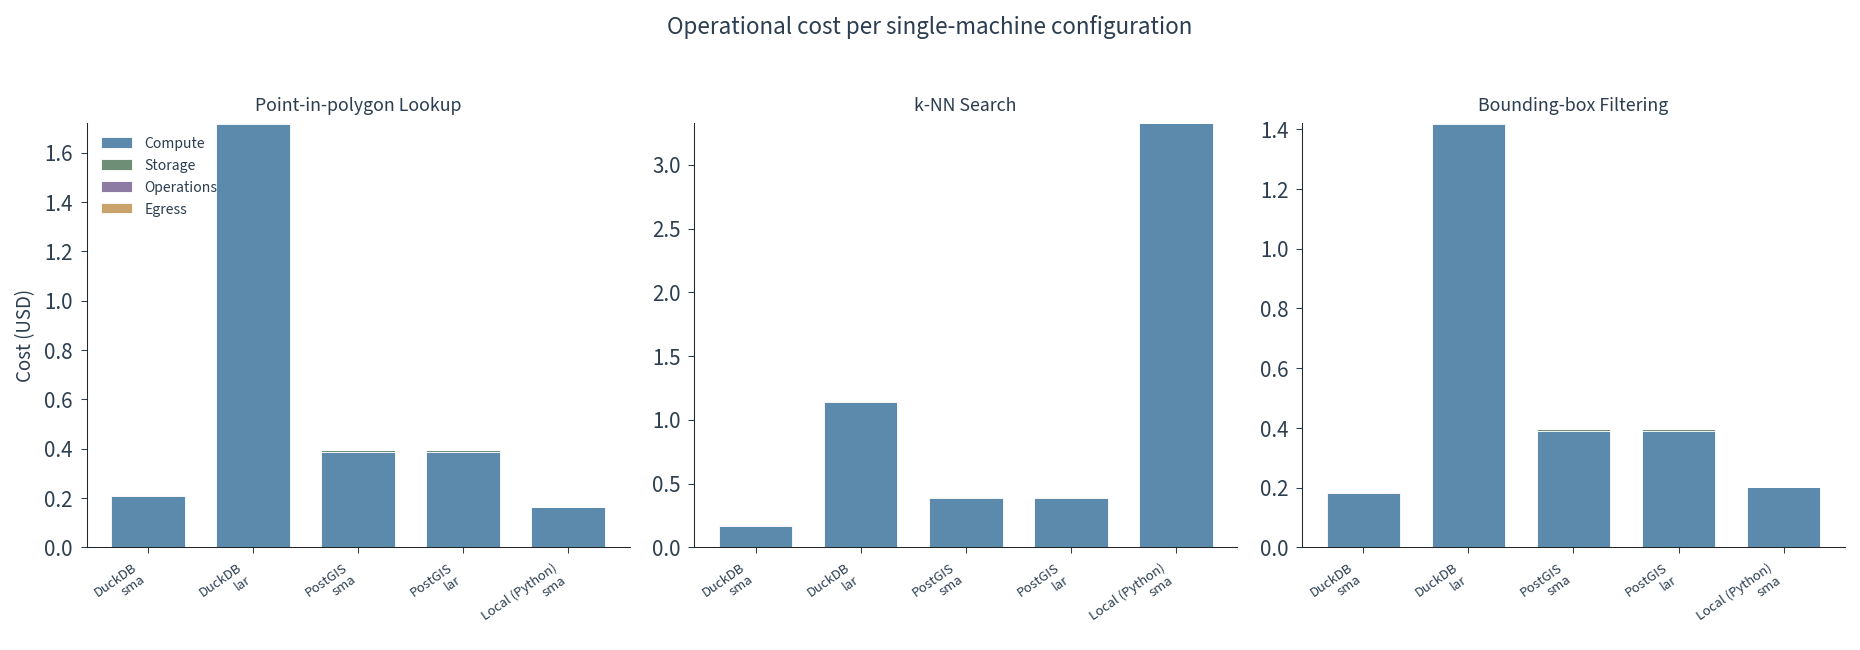

PosixPath('style-preview/08-operational-cost.png')

In [11]:
rq1_cost = cost_summary[cost_summary.index.get_level_values("workload_type").isin(RQ1_W)]
tf.fig_rq1_operational_cost(rq1_cost, RQ1_W, RQ1_C, ["small", "large"], style,
                            PREVIEW / "08-operational-cost.png")

## 9 — Forest plot: Vargha–Delaney A12 with arcuri bands + 0.5 line

**Real function, synthetic data** — feeds `thesis_figures.fig_a12_forest`
(`04-rq3-synthesis` → `06-vargha-delaney-forest.png`) a small representative
`forest_df` (the real forest runs the ~47 s pooled-pairwise bootstrap).

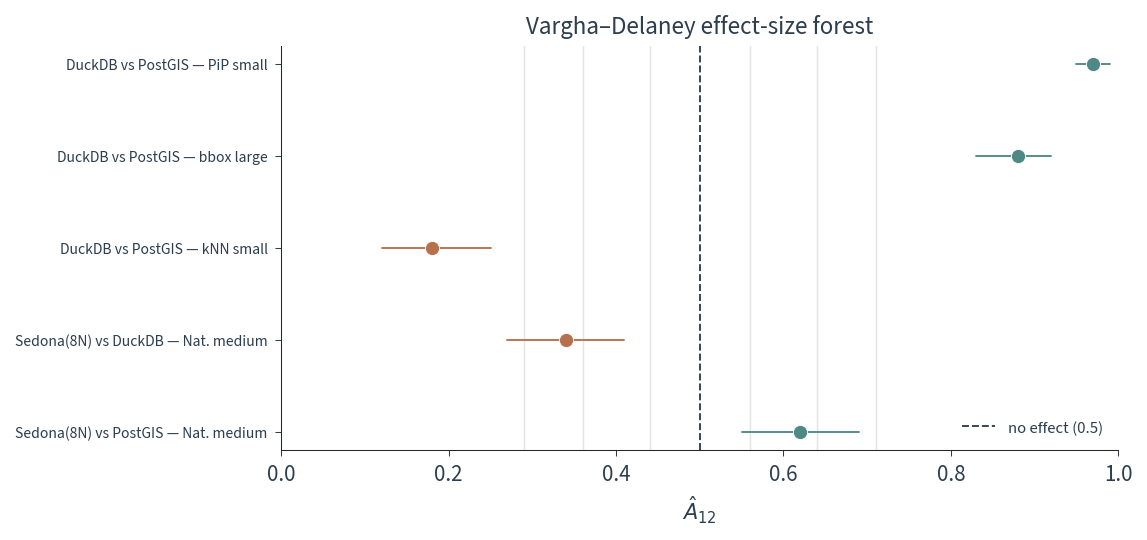

PosixPath('style-preview/09-vargha-delaney-forest.png')

In [12]:
forest_demo = pd.DataFrame([
    {"label": "DuckDB vs PostGIS — PiP small",      "a12": 0.97, "ci_low": 0.95, "ci_high": 0.99},
    {"label": "DuckDB vs PostGIS — bbox large",     "a12": 0.88, "ci_low": 0.83, "ci_high": 0.92},
    {"label": "DuckDB vs PostGIS — kNN small",      "a12": 0.18, "ci_low": 0.12, "ci_high": 0.25},
    {"label": "Sedona(8N) vs DuckDB — Nat. medium", "a12": 0.34, "ci_low": 0.27, "ci_high": 0.41},
    {"label": "Sedona(8N) vs PostGIS — Nat. medium","a12": 0.62, "ci_low": 0.55, "ci_high": 0.69},
])
tf.fig_a12_forest(forest_demo, style, PREVIEW / "09-vargha-delaney-forest.png")

## 10 — Slopegraph / bump: ranking stability across tiers

**Real figure** — `thesis_figures.fig_ranking_stability`
(`04-rq3-synthesis` → `06-ranking-stability.png`); inversions read as crossings.

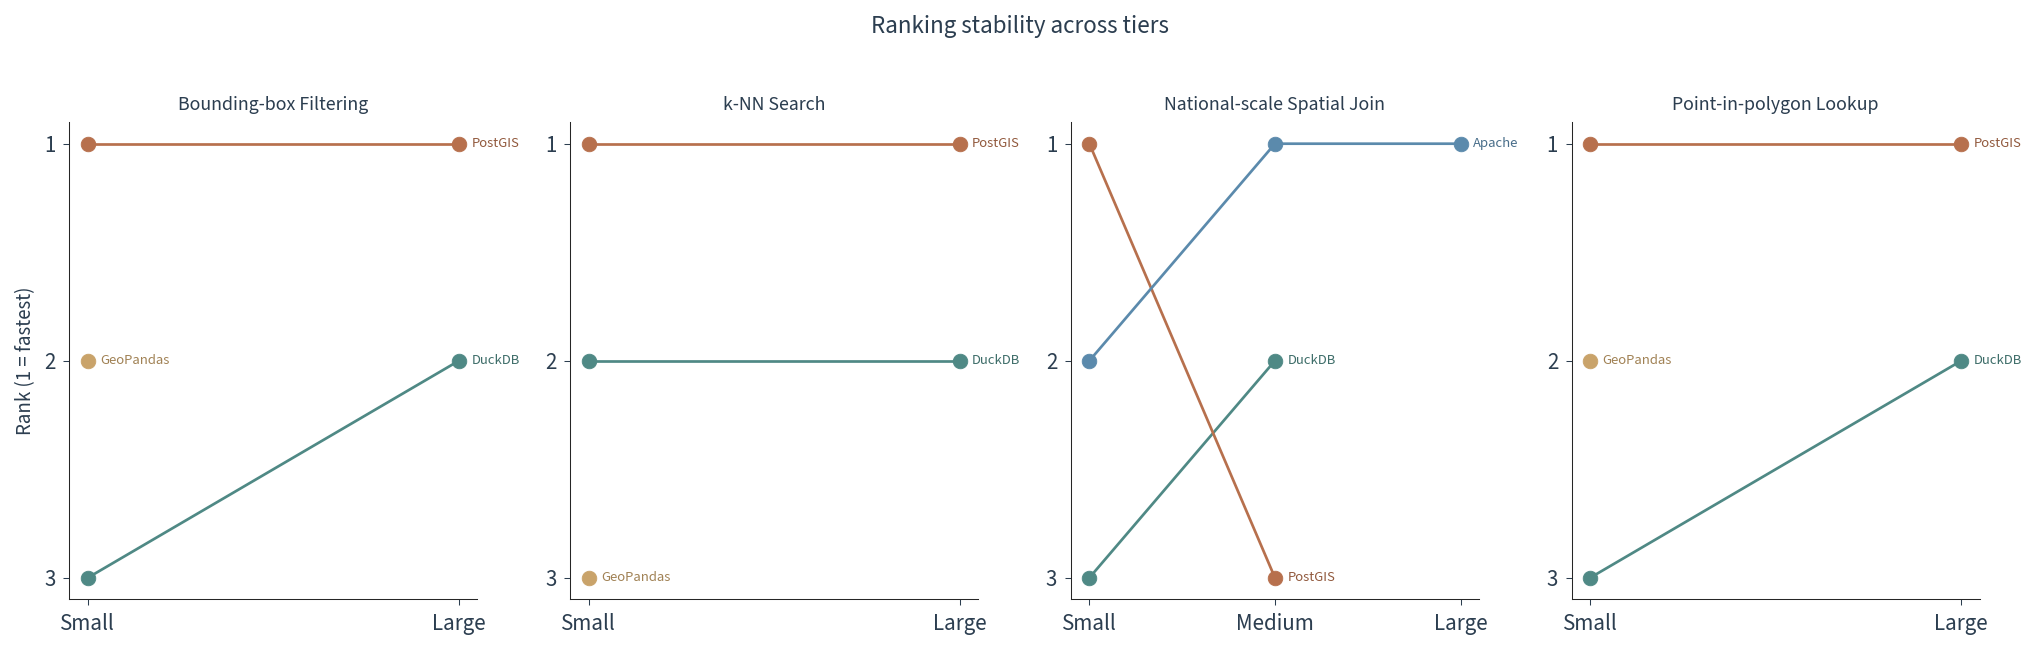

PosixPath('style-preview/10-ranking-stability.png')

In [13]:
tf.fig_ranking_stability(ranks, style, PREVIEW / "10-ranking-stability.png")

---
**Done.** Style preview only. To regenerate the real thesis figures with this
styling, run notebooks `01`–`05` (they write `figures/06-*.png` / `09-*.png`,
then are copied into the thesis chapter figure dirs).